## Trilha Acadêmica - Entrega 02 Redes Neurais Convolucionais (CNNs)
#### Lília Gavazza
#### 11/05

## Introdução

Este notebook investiga a aplicação de Redes Neurais Convolucionais (CNNs) na classificação automática de imagens microscópicas de células sanguíneas.

O objetivo principal é distinguir entre:
- células leucêmicas (ALL)
- células saudáveis (HEM)

Além disso, o projeto compara o desempenho de uma CNN com e sem técnicas de augmentation. A proposta busca  analisar como o aumento artificial da variabilidade das imagens influencia a capacidade de generalização do modelo.

## Contextualização biomédica

A leucemia é um tipo de câncer hematológico caracterizado pela proliferação anormal de células sanguíneas imaturas na medula óssea. O diagnóstico tradicional normalmente envolve análise microscópica realizada por especialistas, processo que pode ser demorado e subjetivo.

Nesse contexto, métodos de inteligência artificial e visão computacional surgem como ferramentas promissoras para auxiliar no diagnóstico médico, permitindo maior velocidade e padronização.

## O que são Redes Neurais Convolucionais (CNNs)

Redes Neurais Convolucionais são arquiteturas de deep learning especializadas em processamento de imagens.

Diferentemente de redes neurais tradicionais, CNNs conseguem explorar relações espaciais presentes nas imagens por meio da operação de convolução.

As principais etapas de uma CNN incluem:
- convolução,
- aplicação de funções de ativação,
- pooling,
- camadas totalmente conectadas

Durante a operação de convolução, as dimensões espaciais da imagem tendem a diminuir progressivamente. O padding é uma técnica utilizada para adicionar bordas artificiais à imagem antes da convolução, normalmente preenchidas com zeros. Essa estratégia possui duas principais vantagens: preservar informações próximas às bordas da imagem e controlar a redução dimensional ao longo da rede.

Neste projeto foi utilizado padding = 1, permitindo manter as dimensões espaciais após as convoluções.

### Etapa Convolucional

A camada convolucional é responsável pela extração de características importantes das imagens de entrada. Ela aplica um conjunto de filtros aprendíveis (*kernels*) que percorrem a imagem realizando operações matemáticas entre os pesos do filtro e pequenas regiões locais da imagem. O resultado dessas operações gera representações conhecidas como mapas de características.

Esses mapas permitem que a rede neural identifique padrões relevantes presentes nas imagens microscópicas, como bordas, texturas, formatos celulares e estruturas associadas às células leucêmicas.

A operação de convolução pode ser representada matematicamente por:
$$
(I \times K)(i, j) = \sum_m \sum_n I(i-m, j-n)K(m, n)
$$
Onde:

$I$ representa a imagem,

$K$ representa o kernel convolucional,

e o resultado corresponde à extração de características locais da imagem.

### Função de Ativação - ReLU

A ReLU introduz não-linearidade na rede neural, permitindo que o modelo aprenda padrões complexos presentes nas imagens.

Além disso, essa função apresenta vantagens importantes como simplicidade computacional, treinamento mais rápido e redução do problema de desaparecimento do gradiente.

### Pooling

A camada de pooling é utilizada para reduzir as dimensões espaciais dos mapas de características produzidos pelas convoluções. Essa redução torna o processamento computacional mais eficiente, diminuindo o custo computacional, o risco de overfitting e garantindo maior robustez a pequenas variações espaciais

As camadas de pooling são normalmente inseridas entre camadas convolucionais em XNNs. O processo consiste em deslizar um filtro bidimensional sobre cada canal do mapa de características, resumindo as informações contidas na região coberta pelo filtro.


Neste projeto foi utilizado o Max Pooling, técnica que seleciona o maior valor presente em pequenas regiões da imagem, ela pode ser representada por:

$$
y_{i, j} = max_{(m, n)} \in R_{(i, j)} x_{m, n}
$$

Onde:

$R_{i,j}$ representa uma região local da imagem e o maior valor dessa região é selecionado como saída.

Dessa forma, o mapa produzido após o max pooling preserva as características mais proeminentes extraídas pela convolução anterior, como bordas, texturas, contrastes e padrões celulares relevantes.

O Max Pooling geralmente apresenta melhor desempenho em aplicações de visão computacional, pois preserva as informações mais importantes enquanto reduz gradualmente a dimensionalidade das representações internas da rede neural. Além disso, o pooling permite que a rede preserve características importantes enquanto reduz gradualmente o tamanho das representações internas.

### Camadas totalmente conectadas

As camadas totalmente conectadas, também chamadas de camadas densas, são responsáveis pela etapa final de classificação da rede neural. Após as camadas convolucionais e de pooling realizarem a extração de características das imagens, as representações obtidas são transformadas em vetores e enviadas para as camadas totalmente conectadas. Essas camadas realizam um processo de raciocínio de alto nível (*high-level reasoning*) utilizando as características extraídas anteriormente, produzindo os escores finais de classificação para cada classe do problema.

Neste projeto, as camadas totalmente conectadas são responsáveis por determinar se a imagem analisada corresponde a uma célula leucêmica (ALL) ou uma célula saudável (HEM).Essa etapa permite que a CNN combine informações extraídas das diferentes regiões da imagem para tomar a decisão final de classificação. 

## Importações

In [3]:
import kagglehub
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu" #usar gpu se disponível, se n usar cpu
)

print("Dispositivo:", device)

Dispositivo: cpu


## Download Dataset

O dataset utilizado foi o C-NMC Leukemia Classification Dataset, disponibilizado publicamente no Kaggle.

O conjunto contém imagens microscópicas reais de células sanguíneas divididas em duas classes:
- ALL: células leucêmicas
- HEM: células saudáveis

As imagens apresentam elevada similaridade morfológica entre as classes, tornando o problema desafiador e adequado para aplicações de visão computacional biomédica.

In [20]:
dataset = kagglehub.dataset_download("nguynhkh/cnmc-blood-cancer-prediction")

In [23]:
print(dataset) # mostra o caminho onde o dataset foi salvo

C:\Users\lilia25019\.cache\kagglehub\datasets\nguynhkh\cnmc-blood-cancer-prediction\versions\1


In [24]:
os.listdir(dataset) # lista o conteúdo da pasta raiz do dataset

['C-NMC Blood Cancer Prediction']

In [31]:
os.listdir(
    os.path.join(
        dataset,
        "C-NMC Blood Cancer Prediction"
    )
) # lista o conteúdo da subpasta do dataset

['C-NMC_Leukemia.sums',
 'C-NMC_test_final_phase_data',
 'C-NMC_test_prelim_phase_data',
 'C-NMC_training_data']

In [32]:
dataset_path = os.path.join(
    dataset,
    "C-NMC Blood Cancer Prediction",
    "C-NMC_training_data"
)

print(dataset_path)
# constroi o caminho para a pasta de treinamento

C:\Users\lilia25019\.cache\kagglehub\datasets\nguynhkh\cnmc-blood-cancer-prediction\versions\1\C-NMC Blood Cancer Prediction\C-NMC_training_data


In [33]:
os.listdir(dataset_path) 
# lista as partições do dataset para a validação cruzada

['fold_0', 'fold_1', 'fold_2']

In [34]:
dataset_path = os.path.join(
    dataset,
    "C-NMC Blood Cancer Prediction",
    "C-NMC_training_data",
    "fold_0"
)

print(os.listdir(dataset_path)) 
# aponta para fold0 que contém as subpastas all e hem

['all', 'hem']


## Data Augmentation

Data augmentation consiste na aplicação de transformações artificiais nas imagens de treinamento com o objetivo de aumentar a variabilidade dos dados. Neste projeto foram utilizadas técnicas como rotações, inversões horizontais e pequenas translações.

Essas transformações ajudam a reduzir overfitting, melhorar a generalização e aumentar a robustez do modelo.

## Transformações

In [35]:
transform_sem_aug = transforms.Compose([  #agrupa multiplas transformações
    transforms.Resize((128,128)),   # padroniza todas as imagens em 128 x 128 pixels
    transforms.ToTensor(),  #Converte para PyTorch e normaliza valores para [0,1]
])

transform_com_aug = transforms.Compose([

    transforms.Resize((128,128)),

    transforms.RandomHorizontalFlip(), #Espelhamento aleatório em 50%

    transforms.RandomRotation(10), #Rotação aleatória de +- 10 graus

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05,0.05) #translação de até 5% em x e y
    ),

    transforms.ToTensor(),
])

## Dataset

In [36]:
dataset_sem_aug = datasets.ImageFolder( #importar as imagens
    root=dataset_path,
    transform=transform_sem_aug
)

dataset_com_aug = datasets.ImageFolder( #importar as imagens
    root=dataset_path,
    transform=transform_com_aug
)

print(dataset_sem_aug.classes) 
print(len(dataset_sem_aug))

['all', 'hem']
3527


## Divisão em treino, teste e validação

O conjunto de dados foi dividido em treino, validação e teste.

O conjunto de treino foi utilizado para atualização dos pesos da rede neural, enquanto conjunto de validação foi utilizado para acompanhar a capacidade de generalização durante o treinamento. Já conjunto de teste foi utilizado apenas na avaliação final do modelo.

In [38]:
train_size = int(0.7 * len(dataset_sem_aug)) # 70% treino
val_size = int(0.15 * len(dataset_sem_aug)) #15% validação
test_size = len(dataset_sem_aug) - train_size - val_size #15% teste

train_sem_aug, val_sem_aug, test_sem_aug = random_split( # divisão embaralha os indices aleatoriamente e separa em treino, teste e validação
    dataset_sem_aug,
    [train_size, val_size, test_size]
)  

train_com_aug, val_com_aug, test_com_aug = random_split(
    dataset_com_aug,
    [train_size, val_size, test_size]
)

print("Treino:", len(train_sem_aug))
print("Validação:", len(val_sem_aug))
print("Teste:", len(test_sem_aug))

Treino: 2468
Validação: 529
Teste: 530


## Dataloaders

Os Data Loaders são responsáveis pelo carregamento e organização dos dados durante o treinamento da rede neural. No PyTorch, os Data Loaders permitem que as imagens sejam fornecidas ao modelo em pequenos grupos denominados batches, em vez de processar todo o conjunto de dados simultaneamente. Essa estratégia apresenta diversas vantagens como um treinamento mais eficiente, maior paralelização computacional e atualização mais estável dos pesos da rede neural.

Além disso, os Data Loaders também permitem o embaralhamento dos dados (*shuffle*), divisão entre treino, validação e teste, e aplicação automática das transformações definidas no pré-processamento. Neste projeto foram utilizados Data Loaders separados para as etapas de treino, validação e teste tanto no experimento sem quanto com data augmentation.

In [39]:
batch_size = 32

train_loader_sem_aug = DataLoader(
    train_sem_aug,
    batch_size=batch_size,
    shuffle=True
) # embaralha os dados a cada época

val_loader_sem_aug = DataLoader(
    val_sem_aug,
    batch_size=batch_size,
    shuffle=False
) # não embaralha na val e teste para reprodutibilidade

test_loader_sem_aug = DataLoader(
    test_sem_aug,
    batch_size=batch_size,
    shuffle=False
)

train_loader_com_aug = DataLoader(
    train_com_aug,
    batch_size=batch_size,
    shuffle=True
)

val_loader_com_aug = DataLoader(
    val_com_aug,
    batch_size=batch_size,
    shuffle=False
)

test_loader_com_aug = DataLoader(
    test_com_aug,
    batch_size=batch_size,
    shuffle=False
)


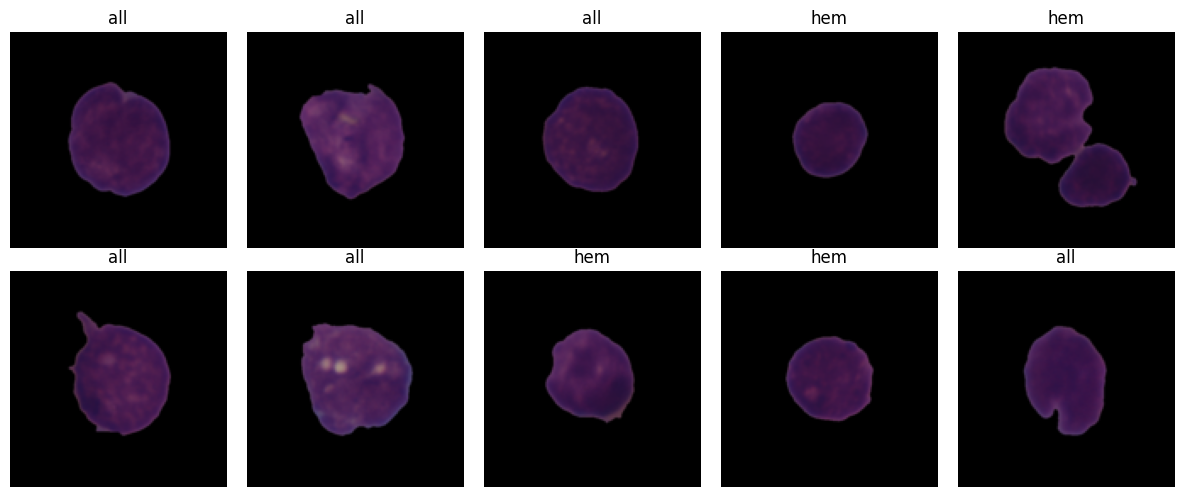

In [40]:
images, labels = next(iter(train_loader_sem_aug))

fig, axes = plt.subplots(2, 5, figsize=(12,5))

for i, ax in enumerate(axes.flat):

    img = images[i].permute(1,2,0) # Reorganiza canais de (C, H, W) para (H, W, C)
# formato esperado pelo matplotlib
    ax.imshow(img)

    ax.set_title(
        dataset_sem_aug.classes[labels[i]]
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

## Definindo a CNN

A arquitetura implementada possui:
- duas camadas convolucionais,
- operações de max pooling,
- funções de ativação ReLU,
- camadas totalmente conectadas

Em que, nesse cado as camadas convolucionais realizam extração progressiva de características relevantes das imagens microscópicas. Já as camadas totalmente conectadas realizam a classificação final entre células saudáveis e leucêmicas.

In [ ]:
class CNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels=3, #RGB
                out_channels=16, #16 filtros
                kernel_size=3, #3x3 
                padding=1 #padding=1 128 x 128(evita perda de bordas preservando dimensões)
            ),

            nn.ReLU(),

            nn.MaxPool2d(2), #reduz pela metade 64x64x16(reduz computação e fornece invariancia translacional)

            nn.Conv2d(
                in_channels=16,
                out_channels=32,#32 filtros -> camadas mais profundas precisam de mais filtros para capturar padrões mais complexos
                kernel_size=3,
                padding=1#mantém 64x64
            ),

            nn.ReLU(),

            nn.MaxPool2d(2) #reduz pela metaed 32x32x32
        )

        self.fc = nn.Sequential(

            nn.Flatten(),#transforma tensor 3D em vetor 32x32x32

            nn.Linear(
                32 * 32 * 32,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                2
            )
        )

    def forward(self, x):q

        x = self.conv(x)

        x = self.fc(x)

        return x

## Função de treinamento com validação

In [43]:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=10
):

    criterion = nn.CrossEntropyLoss() 
    #CrossEntropyLoss penaliza o modelo quando ele dá baixa probabilidade à classe correta, 
    #forçando-o a aprender a fazer predições confiantes e corretas. (loss)

    optimizer = optim.Adam(# otimizador adam (pesos da rede)
        #define como os pesos da rede são ajustados a cada iteração, usando os gradientes calculados pelo backpropagation.
        #Parâmetros com gradientes grandes recebem passos menores; parâmetros raros recebem passos maiores 
        model.parameters(),
        lr=0.001 
    )

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    model.to(device)

    for epoch in range(epochs):

        # Treino

        model.train()

        running_loss = 0

        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad() #zera gradientes anteriores 

            outputs = model(images) #forward pass

            loss = criterion( #calcula erro
                outputs,
                labels
            )

            loss.backward() # backpropagation

            optimizer.step() #atualizar pesos

            running_loss += loss.item()

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

        train_loss = (
            running_loss / len(train_loader)
        )

        train_acc = correct / total

        # Validação

        model.eval() # desativa batch para usar estatisticas acumuladas 

        val_running_loss = 0

        val_correct = 0
        val_total = 0

        with torch.no_grad(): # desativa cálculo de gradientes 
            #não haerá backpropagation na validação - inutil - diminuir custo computacional

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

                val_running_loss += loss.item()

                _, predicted = torch.max( # tem shape com scores para all e hem -> maior pontuação classe prevista
                    outputs,
                    1
                )

                val_total += labels.size(0)

                val_correct += (
                    predicted == labels
                ).sum().item()

        val_loss = (
            val_running_loss / len(val_loader)
        )

        val_acc = val_correct / val_total

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    return (
        train_losses,
        val_losses,
        train_accuracies,
        val_accuracies
    )

## Treinamento sem augmentation

In [44]:
model_sem_aug = CNN()

(
    train_loss_sem,
    val_loss_sem,
    train_acc_sem,
    val_acc_sem

) = train_model(

    model_sem_aug,

    train_loader_sem_aug,

    val_loader_sem_aug,

    epochs=10
)

Epoch 1/10 | Train Loss: 0.5795 | Val Loss: 0.4422 | Train Acc: 0.7168 | Val Acc: 0.8072
Epoch 2/10 | Train Loss: 0.4514 | Val Loss: 0.4307 | Train Acc: 0.8140 | Val Acc: 0.8185
Epoch 3/10 | Train Loss: 0.4348 | Val Loss: 0.4509 | Train Acc: 0.8189 | Val Acc: 0.8204
Epoch 4/10 | Train Loss: 0.4329 | Val Loss: 0.4322 | Train Acc: 0.8241 | Val Acc: 0.8204
Epoch 5/10 | Train Loss: 0.4185 | Val Loss: 0.4344 | Train Acc: 0.8323 | Val Acc: 0.8147
Epoch 6/10 | Train Loss: 0.4111 | Val Loss: 0.4334 | Train Acc: 0.8306 | Val Acc: 0.8185
Epoch 7/10 | Train Loss: 0.4115 | Val Loss: 0.4170 | Train Acc: 0.8254 | Val Acc: 0.8091
Epoch 8/10 | Train Loss: 0.4087 | Val Loss: 0.4314 | Train Acc: 0.8274 | Val Acc: 0.8110
Epoch 9/10 | Train Loss: 0.3938 | Val Loss: 0.4354 | Train Acc: 0.8318 | Val Acc: 0.8091
Epoch 10/10 | Train Loss: 0.3804 | Val Loss: 0.4529 | Train Acc: 0.8416 | Val Acc: 0.7958


## Treinamento com augmentation

In [45]:
model_com_aug = CNN()

(
    train_loss_aug,
    val_loss_aug,
    train_acc_aug,
    val_acc_aug

) = train_model(

    model_com_aug,

    train_loader_com_aug,

    val_loader_com_aug,

    epochs=10
)

Epoch 1/10 | Train Loss: 0.6095 | Val Loss: 0.4849 | Train Acc: 0.6734 | Val Acc: 0.6957
Epoch 2/10 | Train Loss: 0.5070 | Val Loss: 0.4949 | Train Acc: 0.6957 | Val Acc: 0.8053
Epoch 3/10 | Train Loss: 0.4993 | Val Loss: 0.4614 | Train Acc: 0.7950 | Val Acc: 0.8129
Epoch 4/10 | Train Loss: 0.4951 | Val Loss: 0.4665 | Train Acc: 0.8031 | Val Acc: 0.8431
Epoch 5/10 | Train Loss: 0.4882 | Val Loss: 0.4592 | Train Acc: 0.8104 | Val Acc: 0.8412
Epoch 6/10 | Train Loss: 0.4854 | Val Loss: 0.4534 | Train Acc: 0.8156 | Val Acc: 0.8147
Epoch 7/10 | Train Loss: 0.4851 | Val Loss: 0.4461 | Train Acc: 0.8160 | Val Acc: 0.8299
Epoch 8/10 | Train Loss: 0.4760 | Val Loss: 0.4450 | Train Acc: 0.8148 | Val Acc: 0.8374
Epoch 9/10 | Train Loss: 0.4685 | Val Loss: 0.4664 | Train Acc: 0.8209 | Val Acc: 0.8318
Epoch 10/10 | Train Loss: 0.4656 | Val Loss: 0.4298 | Train Acc: 0.8156 | Val Acc: 0.8280


## Curvas de Treinamento

As curvas de perda e acurácia permitem analisar o comportamento do treinamento ao longo das épocas. A comparação entre treino e validação permite identificar possíveis sinais de overfitting, underfitting e capacidade de generalização do modelo.

### Curva de Perda

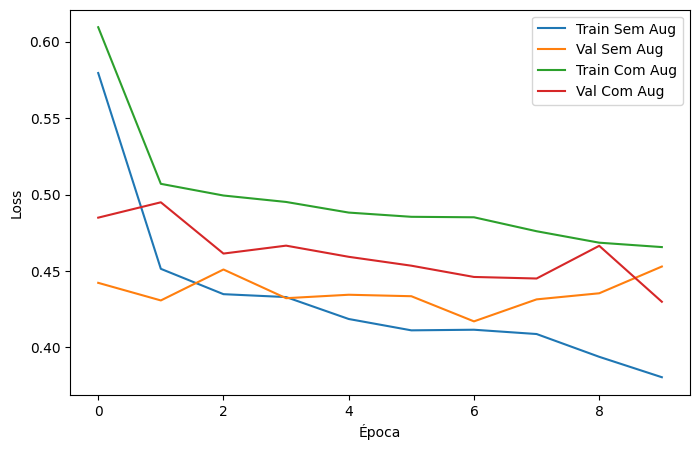

In [46]:
plt.figure(figsize=(8,5))

plt.plot(
    train_loss_sem,
    label="Train Sem Aug"
)

plt.plot(
    val_loss_sem,
    label="Val Sem Aug"
)

plt.plot(
    train_loss_aug,
    label="Train Com Aug"
)

plt.plot(
    val_loss_aug,
    label="Val Com Aug"
)

plt.xlabel("Época")
plt.ylabel("Loss")

plt.legend()

plt.show()

#curva azul diminui
# curva laranja aumenta - OVERFITTING
# curva verde diminui lentamente
# estável
# - ambos os modelos convergem, sem aug overfitting, com aug melhor generalização (n aumenta)

### Curva de acurácia

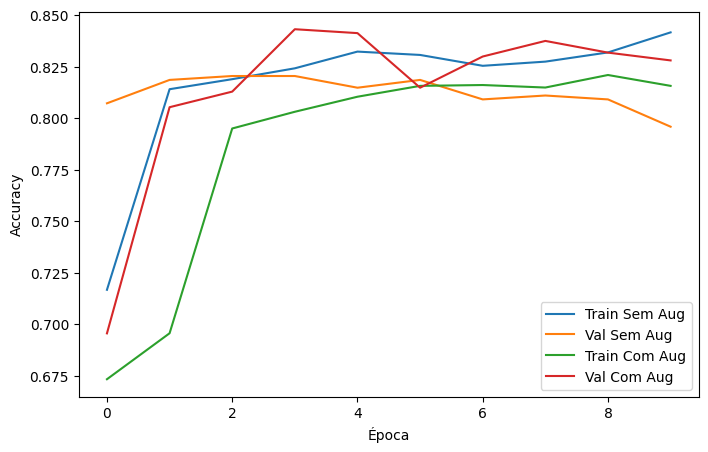

In [47]:
plt.figure(figsize=(8,5))

plt.plot(
    train_acc_sem,
    label="Train Sem Aug"
)

plt.plot(
    val_acc_sem,
    label="Val Sem Aug"
)

plt.plot(
    train_acc_aug,
    label="Train Com Aug"
)

plt.plot(
    val_acc_aug,
    label="Val Com Aug"
)

plt.xlabel("Época")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

## Função de avaliação

In [48]:
def evaluate_model(model, loader):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            _, predicted = torch.max(
                outputs,
                1
            )

            y_true.extend(
                labels.numpy()
            )

            y_pred.extend(
                predicted.cpu().numpy()
            )

    return y_true, y_pred

## Teste sem augmentation

In [49]:
y_true_sem, y_pred_sem = evaluate_model(
    model_sem_aug,
    test_loader_sem_aug
)

print(
    classification_report(
        y_true_sem,
        y_pred_sem,
        target_names=dataset_sem_aug.classes
    )
)
# precision: das celulas que o modelo disse que eram all, 85% eram
# recall: das n celulas all, o modelo detectou 87%
# f1: média harmonica entre precision e recall

              precision    recall  f1-score   support

         all       0.83      0.87      0.85       343
         hem       0.75      0.68      0.71       187

    accuracy                           0.81       530
   macro avg       0.79      0.78      0.78       530
weighted avg       0.80      0.81      0.80       530



## Matrizes de Confusão

As matrizes de confusão permitem visualizar detalhadamente os acertos e erros do modelo.

Em aplicações biomédicas, erros de classificação possuem relevância clínica significativa, especialmente falsos negativos, nos quais células leucêmicas são classificadas incorretamente como saudáveis.

### Matriz de confusão - sem augmentation

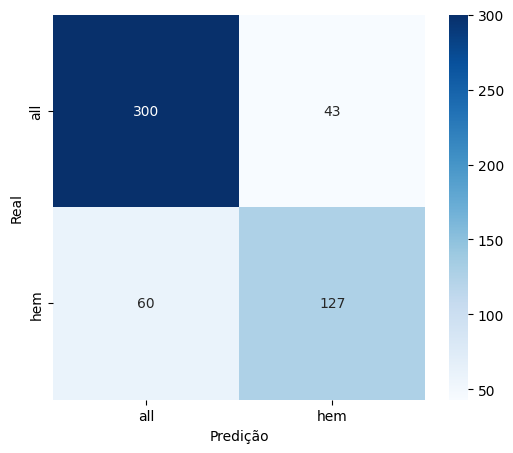

In [50]:
cm = confusion_matrix(
    y_true_sem,
    y_pred_sem
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=dataset_sem_aug.classes,
    yticklabels=dataset_sem_aug.classes
)

plt.xlabel("Predição")
plt.ylabel("Real")

plt.show()

## Teste com augmentation

In [51]:
y_true_aug, y_pred_aug = evaluate_model(
    model_com_aug,
    test_loader_com_aug
)

print(
    classification_report(
        y_true_aug,
        y_pred_aug,
        target_names=dataset_com_aug.classes
    )
)

              precision    recall  f1-score   support

         all       0.85      0.95      0.89       367
         hem       0.83      0.62      0.71       163

    accuracy                           0.85       530
   macro avg       0.84      0.78      0.80       530
weighted avg       0.84      0.85      0.84       530



### Matriz de confusão - com augmentation

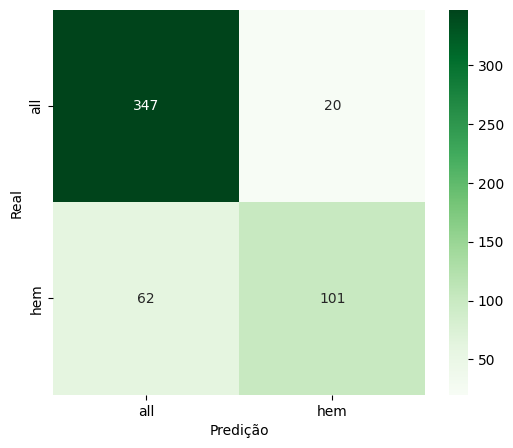

In [52]:
cm = confusion_matrix(
    y_true_aug,
    y_pred_aug
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=dataset_com_aug.classes,
    yticklabels=dataset_com_aug.classes
)

plt.xlabel("Predição")
plt.ylabel("Real")

plt.show()

## Conclusão

A análise das curvas de treinamento demonstra que ambos os modelos apresentaram convergência estável ao longo das épocas, com redução progressiva da função de perda e aumento da acurácia. O modelo treinado sem data augmentation apresentou menor perda de treinamento e maior acurácia final de treino, indicando maior capacidade de ajuste aos dados originais. Entretanto, a diferença crescente entre as curvas de treino e validação sugere a presença de certo grau de overfitting, isto é, o modelo tornou-se mais especializado nos exemplos vistos durante o treinamento.

Por outro lado, o modelo treinado com data augmentation apresentou treinamento mais regularizado. Embora a acurácia de treinamento tenha sido ligeiramente inferior, as curvas de validação mostraram comportamento mais estável, indicando melhor capacidade de generalização para imagens não vistas anteriormente.

As matrizes de confusão reforçam esse comportamento. O modelo com augmentation aumentou significativamente o número de células leucêmicas corretamente classificadas (ALL), passando de 300 para 347 acertos, além de reduzir substancialmente os falsos negativos dessa classe (de 43 para 20). Esse resultado é muito importante em aplicações biomédicas, pois falsos negativos representam células cancerígenas classificadas incorretamente como saudáveis.

Entretanto, o modelo com *augmentation* apresentou pior desempenho na identificação das células saudáveis (*HEM*), reduzindo os acertos dessa classe de 127 para 101 e aumentando a quantidade de células saudáveis classificadas incorretamente como leucêmicas.

Esses resultados sugerem que o *data augmentation* tornou o modelo mais sensível à detecção de células leucêmicas, favorecendo a identificação de padrões associados à doença. Em contextos clínicos, esse comportamento pode ser desejável, já que minimizar falsos negativos normalmente possui maior prioridade diagnóstica do que minimizar falsos positivos.

## Referências

1. GEEKSFORGEEKS. Introduction to Pooling Layer in CNN. Disponível em: <https://www.geeksforgeeks.org/deep-learning/introduction-to-pooling-layer-cnn/>.
2. GEEKSFORGEEKS. What are Convolution Layers? Disponível em: <https://www.geeksforgeeks.org/machine-learning/what-are-convolution-layers/>.
3. GEEKSFORGEEKS. Introduction to Convolution Neural Network. Disponível em: <https://www.geeksforgeeks.org/machine-learning/introduction-convolution-neural-network/>.
4. WIKIPEDIA CONTRIBUTORS. Convolutional neural network. Disponível em: <https://en.wikipedia.org/wiki/Convolutional_neural_network>.
5. LUNA, J. C. PyTorch CNN Tutorial: Crie e treine redes neurais convolucionais em Python. Disponível em: <https://www.datacamp.com/pt/tutorial/pytorch-cnn-tutorial>. Acesso em: 10 maio. 2026.
6. Transforming and augmenting images — Torchvision 0.22 documentation. Disponível em: <https://docs.pytorch.org/vision/stable/transforms.html>.
7. SUN, E. A Practical Guide for Data Augmentation to Increase Model Accuracy in PyTorch. Disponível em: <https://medium.com/@BurtMcGurt/a-practical-guide-to-data-augmentation-in-pytorch-with-examples-and-visualizations-761ad5c2a903>.‌